### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [85]:
df = pd.read_csv('./data/RELIANCE.csv')

In [86]:
df.loc[df.index[-1],'Open'] = df.iloc[-2]['Close']

In [89]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2634.000000,2634.000000,2634.000000,2634.000000,2634.000000,2.634000e+03
mean,593.965357,600.787471,586.714278,593.416973,556.435824,8.622828e+06
std,264.088329,266.530348,261.098518,263.770466,278.365257,5.485415e+06
min,272.774994,286.250000,266.250000,269.388000,222.757553,0.000000e+00
25%,432.656250,437.500000,426.962509,432.125000,391.739197,5.316242e+06
50%,497.375000,502.500000,491.550003,496.649994,445.431839,7.126298e+06
75%,556.762512,565.875000,546.812500,554.640991,524.052490,1.009307e+07
max,1407.949951,1417.500000,1402.650024,1408.849976,1401.091064,8.624427e+07


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2634 entries, 0 to 2633
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2634 non-null   object 
 1   Open       2634 non-null   float64
 2   High       2634 non-null   float64
 3   Low        2634 non-null   float64
 4   Close      2634 non-null   float64
 5   Adj Close  2634 non-null   float64
 6   Volume     2634 non-null   float64
dtypes: float64(6), object(1)
memory usage: 144.2+ KB


### Step 3: Feature Engineering

In [90]:
df['Open-Close'] = df['Open'] - df['Close']
df['High-Low'] = df['High'] - df['Low']

In [91]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low
0,2009-01-02,314.924988,324.975006,313.000000,321.600006,265.931763,19847448.0,-6.675018,11.975006
1,2009-01-05,324.750000,344.250000,323.774994,341.462006,282.355743,22027876.0,-16.712006,20.475006
2,2009-01-06,340.000000,347.500000,332.812012,342.725006,283.400116,24118400.0,-2.725006,14.687988
3,2009-01-07,342.250000,346.500000,293.750000,300.187988,248.226151,34002200.0,42.062012,52.750000
4,2009-01-09,302.500000,302.500000,273.412994,288.312012,238.405838,37952520.0,14.187988,29.087006


### Step 4: Exploratory Data Analysis

In [94]:
df['Date'] = pd.to_datetime(df['Date'])

In [95]:
df.set_index('Date', inplace=True)

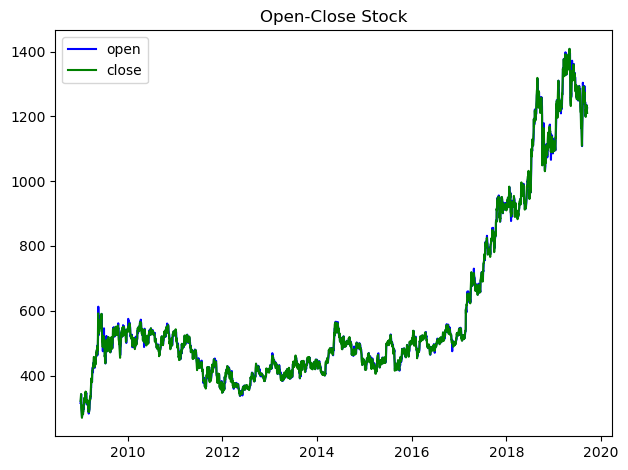

In [41]:
plt.plot(df['Open'], c='blue', label='open')
plt.plot(df['Close'], c='green', label='close')
plt.title('Open-Close Stock')
plt.legend()
plt.tight_layout()

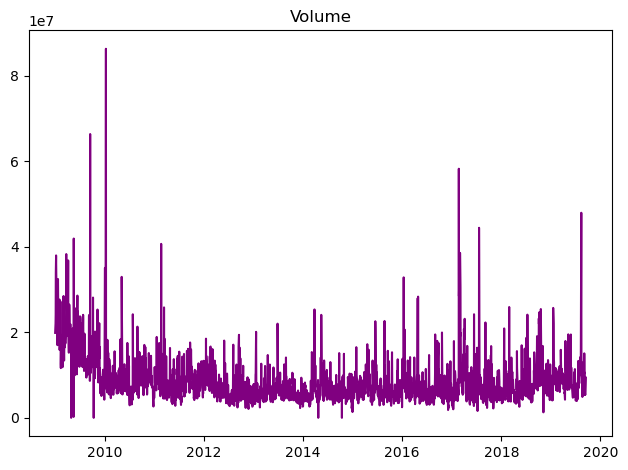

In [42]:
plt.plot(df['Volume'], c='purple')
plt.title('Volume')
plt.tight_layout()

<Axes: >

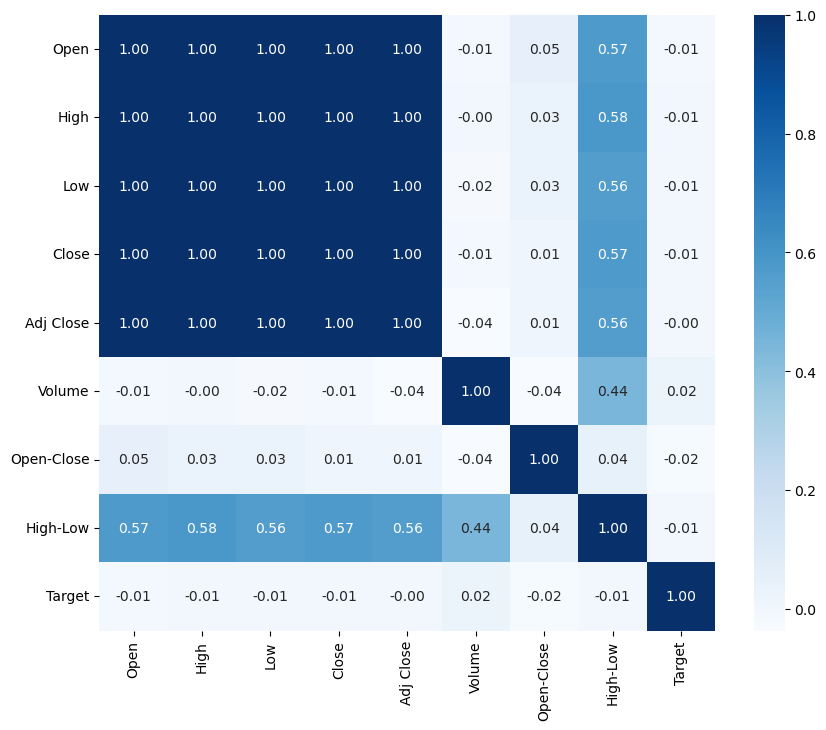

In [54]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(np.number).corr(), cmap=plt.cm.Blues, annot=True, square=True, fmt='.2f')

### Step 5: Preparing Data

In [117]:
scaler = StandardScaler()

In [118]:
scaler_data = scaler.fit_transform(df)

In [119]:
scaler_df = pd.DataFrame(scaler_data, columns=df.columns)

In [123]:
scaler_df.head()

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low
0,-1.056818,-1.035022,-1.048517,-1.030701,-1.043806,2.046655,-0.706535,-0.221388
1,-1.019608,-0.962690,-1.007241,-0.955387,-0.984793,2.444226,-1.688273,0.675480
2,-0.961851,-0.950494,-0.972623,-0.950598,-0.981040,2.825404,-0.320177,0.064869
3,-0.953329,-0.954247,-1.122258,-1.111893,-1.107423,4.627579,4.060530,4.080940
4,-1.103876,-1.119363,-1.200163,-1.156926,-1.142709,5.347865,1.334117,1.584166


In [124]:
X_data = scaler_df[['Close', 'Volume', 'Open-Close', 'High-Low']]
y_data = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    test_size=0.2,
    random_state=42
)

### Step 6:Model Development

In [126]:
cls = SVC().fit(X_train, y_train)

### Step 7: Model Evaluation

In [127]:
train_accuracy = accuracy_score(y_train, cls.predict(X_train))
test_accuracy = accuracy_score(y_test, cls.predict(X_test))

In [128]:
print("Training Accuracy: {:.3f}".format(train_accuracy))
print("Testing Accuracy: {:.3f}".format(test_accuracy))

Training Accuracy: 0.563
Testing Accuracy: 0.474


### Step 8: Strategy Implementation

In [129]:
pred = cls.predict(X_data)

In [131]:
df['Predicted_Signal'] = pred

In [132]:
df['Return'] = df.Close.pct_change()

In [137]:
df['Strategy_Return'] = df.Return *df.Predicted_Signal.shift(1)

In [140]:
df['Cum_Ret'] = df['Return'].cumsum()

In [142]:
df['Cum_Strategy'] = df['Strategy_Return'].cumsum()

In [148]:
df.tail()

,Open,High,Low,Close,Adj Close,Volume,Open-Close,High-Low,Predicted_Signal,Return,Strategy_Return,Cum_Ret,Cum_Strategy
Date,,,,,,,,,,,,,
2019-09-09,1220.650024,1233.000000,1213.150024,1222.199951,1222.199951,5370758.0,-1.549927,19.849976,0,-0.000245,-0.000245,1.774621,2.709778
2019-09-11,1222.500000,1240.000000,1222.500000,1234.400024,1234.400024,5544468.0,-11.900024,17.500000,0,0.009982,0.000000,1.784603,2.709778
2019-09-12,1235.000000,1240.449951,1205.699951,1210.349976,1210.349976,5431139.0,24.650024,34.750000,0,-0.019483,-0.000000,1.765120,2.709778
2019-09-13,1212.000000,1228.500000,1206.900024,1225.599976,1225.599976,5919260.0,-13.599976,21.599976,1,0.012600,0.000000,1.777720,2.709778
2019-09-16,1225.599976,1219.099976,1186.099976,1210.750000,1210.750000,9390427.0,14.849976,33.000000,0,-0.012116,-0.012116,1.765603,2.697662


### Step 9: Visualizing Strategy Returns vs Original Returns

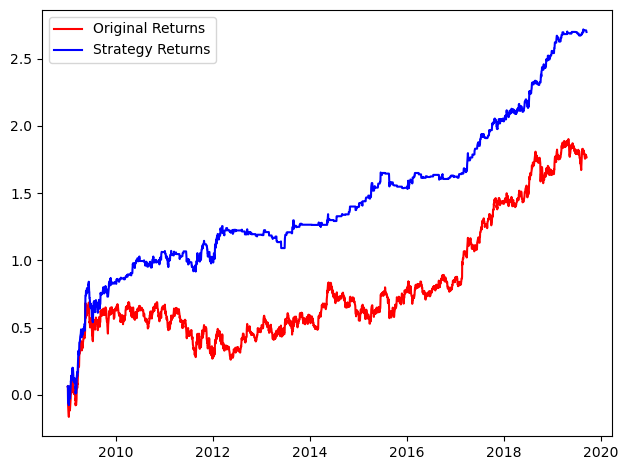

In [147]:
plt.plot(df['Cum_Ret'], color='red', label='Original Returns')
plt.plot(df['Cum_Strategy'], color='blue', label='Strategy Returns')
plt.legend()
plt.tight_layout()